In [1]:
import sys
import os

os.chdir("../")
# Get the absolute path of the 'src' directory
src_path = os.path.abspath(os.path.join(os.getcwd(), ".."))  # Move one level up from 'experiments/'

# Add 'src' to Python's module search path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

In [ ]:
from PiGDM.src.pseudoInverse.pigdm_ddim import DiffusionModel, PiGDM_DDIM
from PiGDM.src.pseudoInverse.pigdm_ddpm import PiGDM_DDPM
from pseudoInverse.operators import SuperResolutionOperator, GrayscaleOperator

from ddpm.model import DDPM
from ddpm.utils import display_as_pilimg, standardize_img, pilimg_to_tensor

from experiments.utils import evaluate_model, ImageDataset, plot_results, compute_psnr, compute_ssim

from torch.utils.data import DataLoader, Subset

import matplotlib.pyplot as plt

import torch

import numpy as np

## Super Resolution

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [5]:
dataset_path = "dataset/ffhq256-1k-validation"
dataset_size = len(os.listdir(dataset_path))

print(f"The Dataset FFHQ Contains : {dataset_size} Images\n")

# Image Dataset Intialization
dataset = ImageDataset(dataset_path)

The Dataset FFHQ Contains : 1000 Images



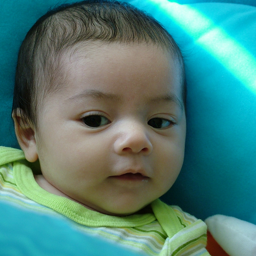

In [6]:
image_1 = display_as_pilimg(dataset[0])

In [7]:
# Loading Data For Test
subset_size = 10
indices = list(range(subset_size)) 

subset = Subset(dataset, indices)  
test_loader_all = DataLoader(subset, batch_size=1, shuffle=False)

### Sampling Using DDIM

In [ ]:
measurement_operator = SuperResolutionOperator()

# Intialize Model
ddpm = DDPM()
model = DiffusionModel(model=ddpm) 

guidance_factor = 0.1

# Initialize sampler
pigdm_sampler = PiGDM_DDIM(model, measurement_operator, guidance_factor=guidance_factor)

  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\Nizar\repos\ML\image_modelling\project\PiGDM\src\ddpm\model.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model_output = self.model(x, torch.tensor(t, device=device).unsqueeze(0))
100%|██████████| 100/100 [00:11<00:00,  8.85it/s]


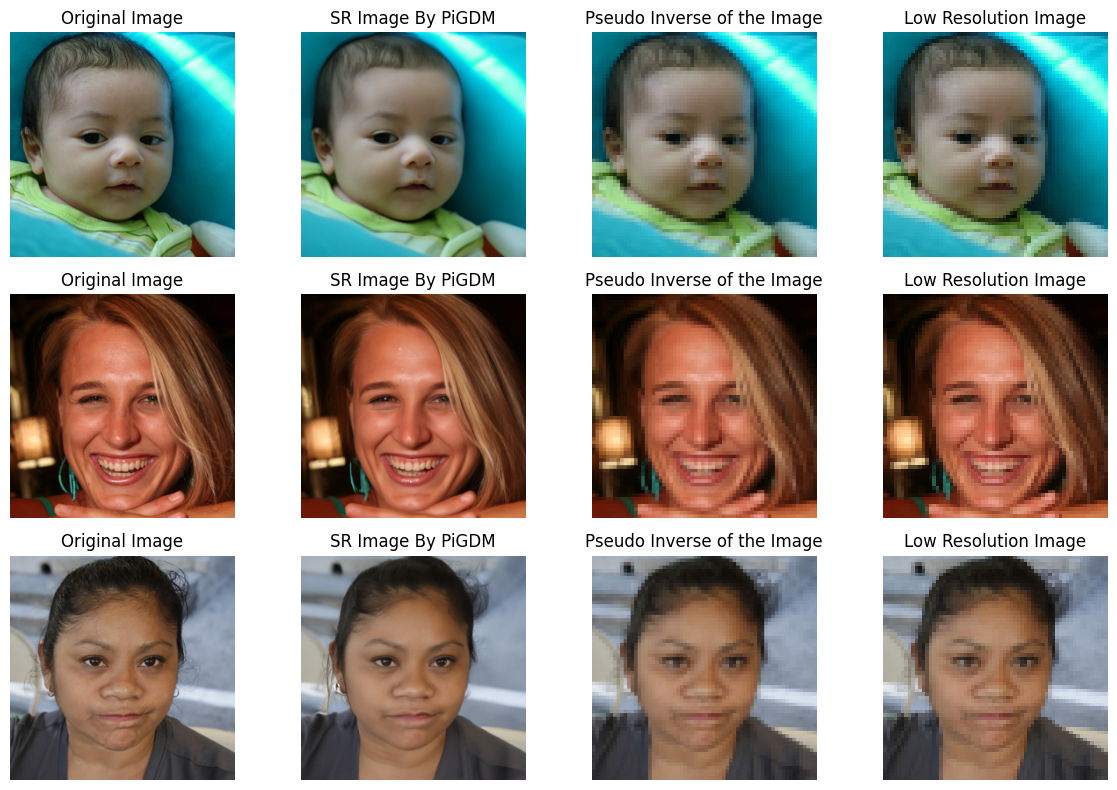

In [9]:
# Running Experiments on The 3 first images
# Noiseless Case

noiseless = True
num_steps = 100
seed = 42

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    sr_image = pigdm_sampler.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(sr_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("SR Image By PiGDM")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Low Resolution Image")



plt.tight_layout()
plt.show()

100%|██████████| 100/100 [00:11<00:00,  8.56it/s]


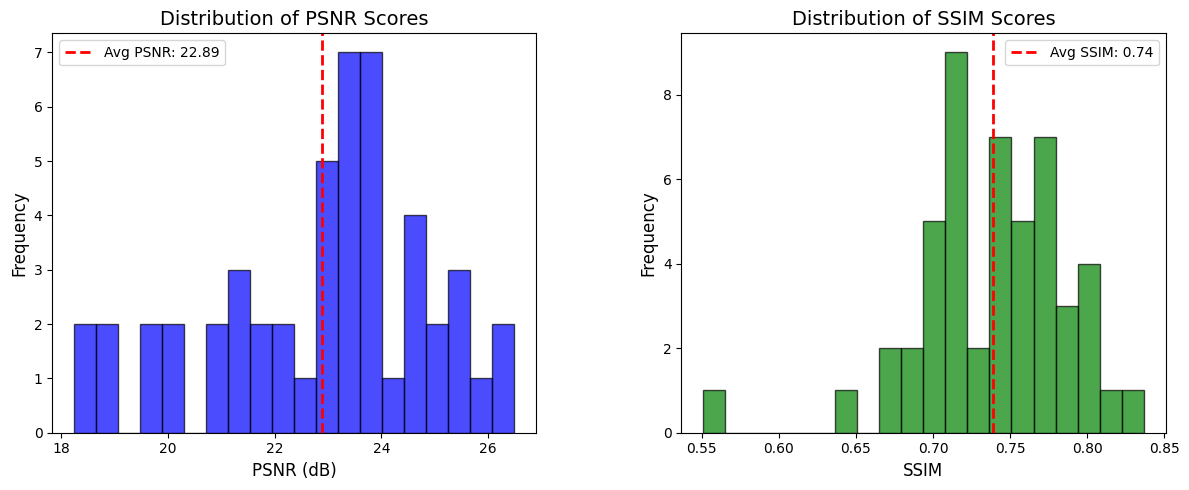

In [22]:
filename = "DDIM_noiseless.png"
folder_name = "experiments/results/super_resolution/"

results_ddim_sr = evaluate_model(pigdm_sampler, test_loader_all, num_steps, sigma_y=None, noiseless=noiseless, seed=seed, device="cuda")
plot_results(results_ddim_sr, filename = filename, save_path = folder_name)

### Sampling with DDPM

In [ ]:
measurement_operator = SuperResolutionOperator()
# Intialize Model
ddpm = DDPM()
model = DiffusionModel(model=ddpm) 

guidance_factor = 0.1

# Initialize sampler
pigdm_sampler = PiGDM_DDPM(model, measurement_operator, guidance_factor=guidance_factor)

100%|██████████| 500/500 [00:56<00:00,  8.88it/s]


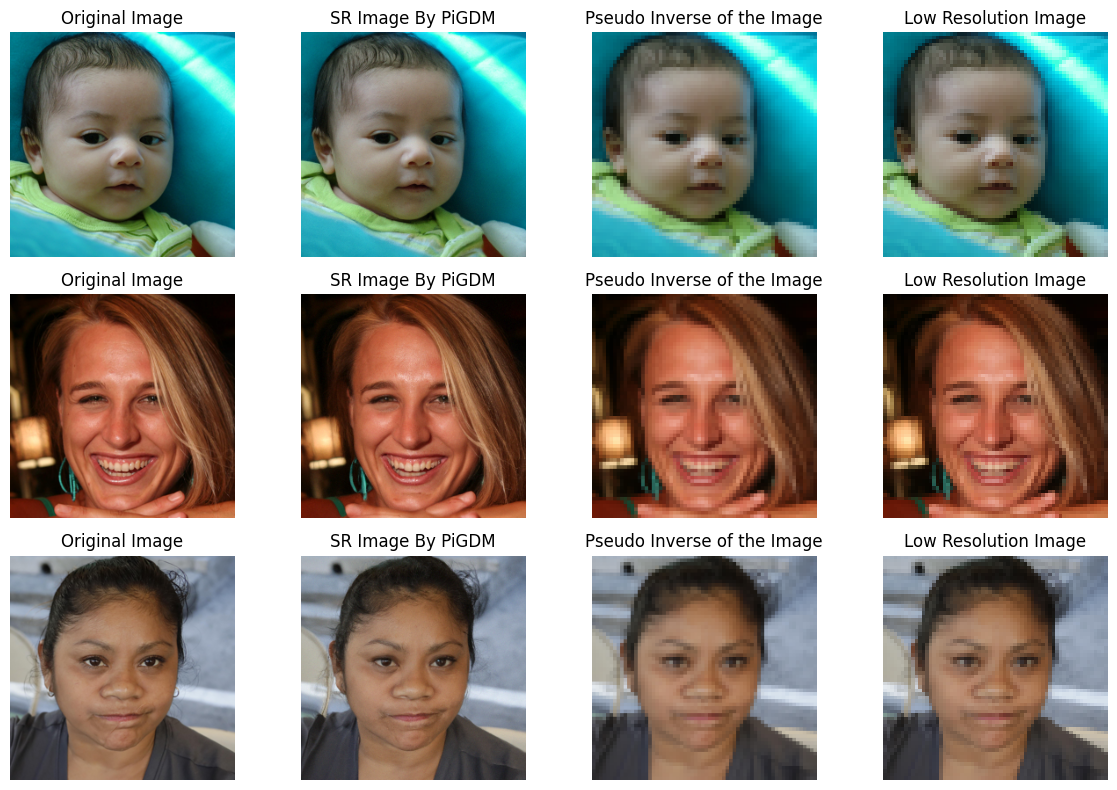

In [8]:
# Running Experiments on The 3 first images
# Noiseless Case

noiseless = True
num_steps = 500
seed = 42

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    sr_image = pigdm_sampler.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(sr_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("SR Image By PiGDM")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Low Resolution Image")



plt.tight_layout()
plt.show()

100%|██████████| 500/500 [00:54<00:00,  9.23it/s]


NameError: name 'file_name' is not defined

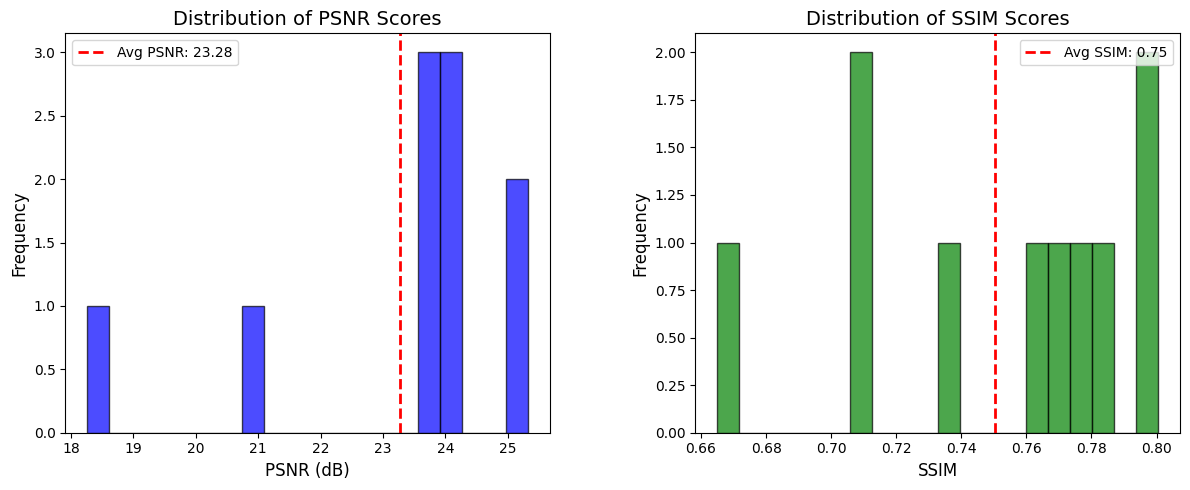

In [9]:
filename = "DDPM_noiseless.png"
folder_name = "experiments/results/super_resolution/"

results_ddpm_sr = evaluate_model(pigdm_sampler, test_loader_all, num_steps, sigma_y=None, noiseless=noiseless, seed=seed, device="cuda")
plot_results(results_ddpm_sr, filename = filename, save_path = "results/super_resolution/")


## Colorization

### DDIM Sampling

In [40]:
measurement_operator = GrayscaleOperator()

# Intialize Model
ddpm = DDPM()
model = DiffusionModel(model=ddpm) 

guidance_factor = 0.1

# Initialize sampler
pigdm_sampler = PiGDM_DDIM(model, measurement_operator, guidance_factor=guidance_factor)

noiseless = True
num_steps = 100
seed = 42

100%|██████████| 100/100 [00:11<00:00,  8.71it/s]


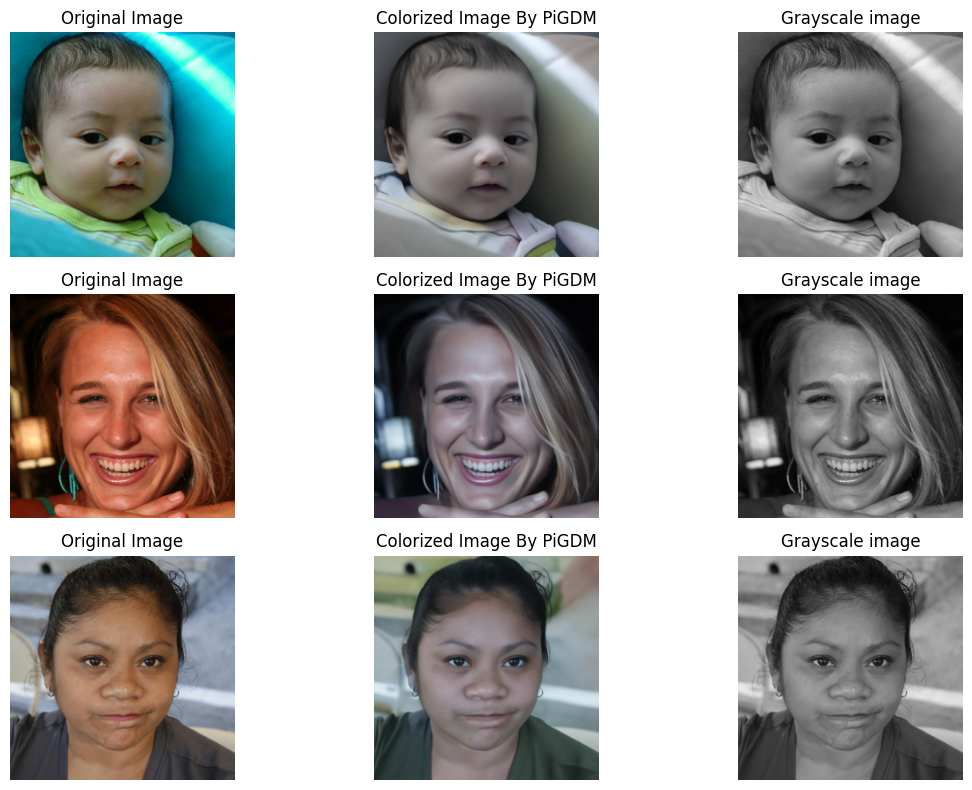

In [13]:
# Running Experiments on The 3 first images

noiseless = True
num_steps = 100
seed = 42

fig, axes = plt.subplots(3, 3, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    colorized_image = pigdm_sampler.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(colorized_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("Colorized Image By PiGDM")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Grayscale image")



plt.tight_layout()
plt.show()

In [41]:
filename = "DDIM_noiseless"
folder_name = "experiments/results/colorization/"

results_ddim_colorization = evaluate_model(pigdm_sampler, test_loader_all, num_steps, sigma_y=None, noiseless=noiseless, seed=seed, device="cuda")


100%|██████████| 100/100 [00:11<00:00,  8.65it/s]


TypeError: plot_results() got an unexpected keyword argument 'file_name'

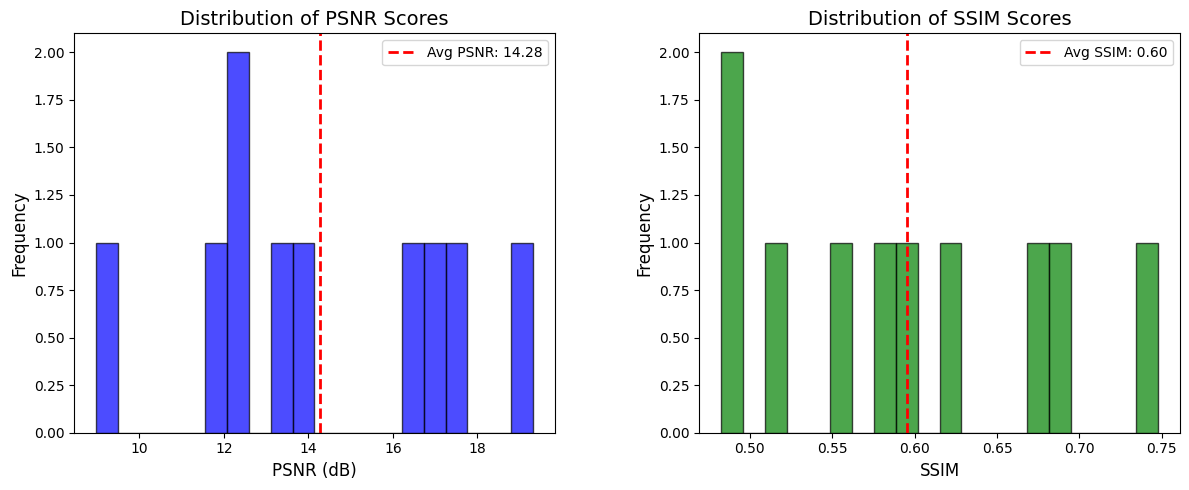

In [42]:
plot_results(results_ddim_colorization, filename=filename, save_path=folder_name)

### DDPM Sampling

In [44]:
# Intialize Model
ddpm = DDPM()
model = DiffusionModel(model=ddpm) 

guidance_factor = 0.01

# Initialize sampler
pigdm_sampler_ddpm = PiGDM_DDPM(model, measurement_operator, guidance_factor=guidance_factor)

noiseless = True
num_steps = 1000
seed = 42

100%|██████████| 1000/1000 [01:53<00:00,  8.84it/s]


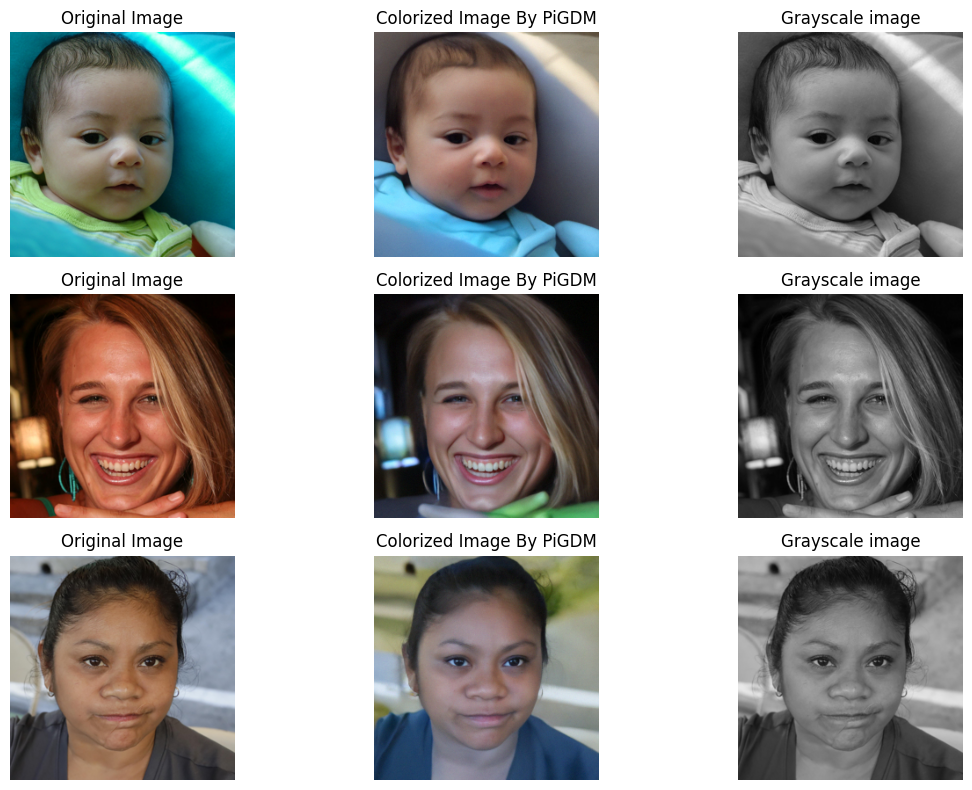

In [25]:
# Running Experiments on The 3 first images

noiseless = True
num_steps = 1000
seed = 42

fig, axes = plt.subplots(3, 3, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))

    colorized_image = pigdm_sampler_ddpm.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        seed=seed
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(colorized_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("Colorized Image By PiGDM")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Grayscale image")



plt.tight_layout()
plt.show()

100%|██████████| 1000/1000 [01:51<00:00,  8.96it/s]


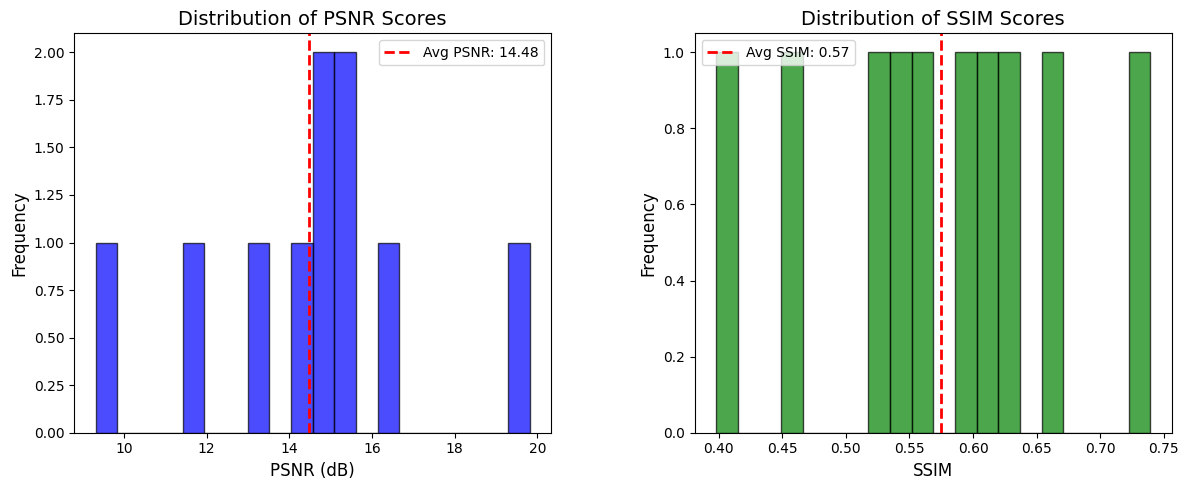

In [45]:
filename = "DDPM_noiseless"
folder_name = "experiments/results/colorization/"

results_ddim_colorization = evaluate_model(pigdm_sampler_ddpm, test_loader_all, num_steps, sigma_y=None, noiseless=noiseless, seed=seed, device="cuda")
plot_results(results_ddim_colorization, filename=filename, save_path = folder_name)

## Noisy SR operator

### DDPM Sampling

In [ ]:
measurement_operator = SuperResolutionOperator()

# Intialize Model
ddpm = DDPM()
model = DiffusionModel(model=ddpm)

guidance_factor = 0.5

# Initialize sampler
pigdm_sampler_ddim = PiGDM_DDIM(model, measurement_operator, guidance_factor=guidance_factor)

100%|██████████| 100/100 [00:11<00:00,  8.90it/s]


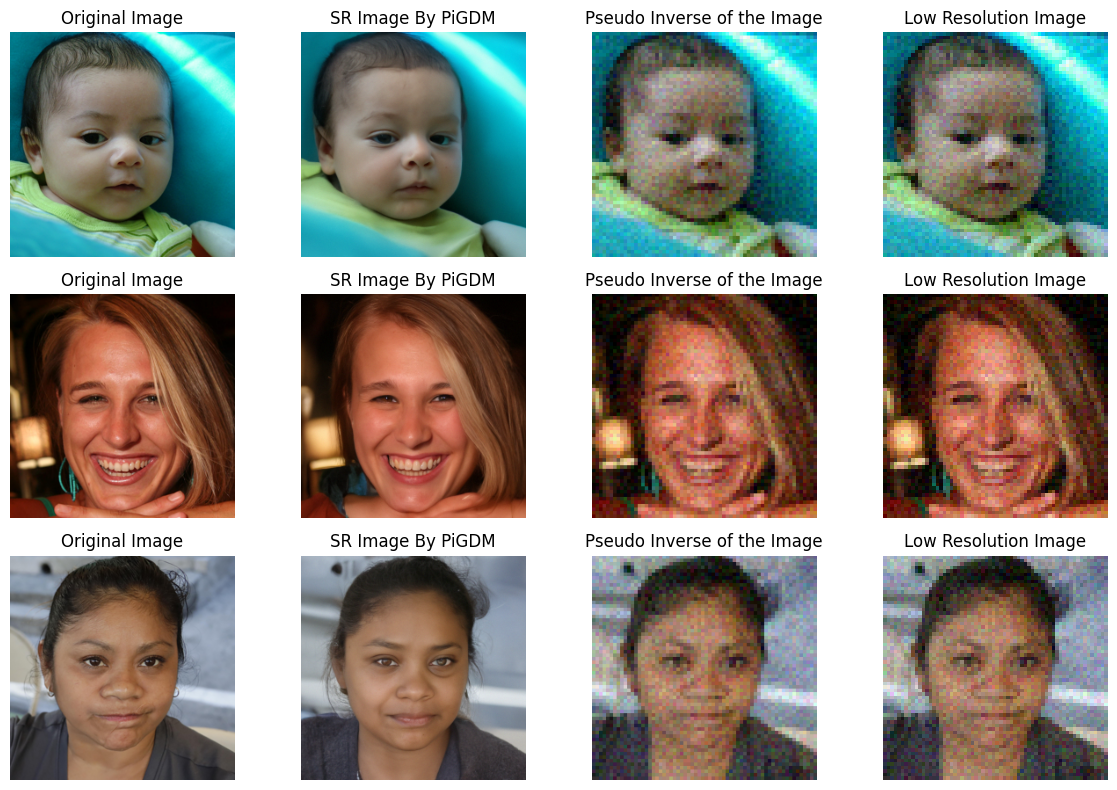

In [36]:
# Running Experiments on The 3 first images
noiseless = False
sigma_y = 0.1
num_steps = 100
seed = 42

fig, axes = plt.subplots(3, 4, figsize=(12, 8))

for i in range(3):
    image = dataset[i].to(device)
    y = measurement_operator(image.unsqueeze(0))
    y += sigma_y * torch.randn_like(y)

    sr_image = pigdm_sampler_ddim.sample(
        y=y,
        num_steps=num_steps,
        noiseless=noiseless,
        sigma_y=sigma_y,
        optimized = True,
        seed=seed,
        
    )

    inversed_image = measurement_operator.pseudoinverse(y)

    axes[i][0].imshow(standardize_img(image))
    axes[i][0].axis('off')
    axes[i][0].set_title("Original Image")

    axes[i][1].imshow(standardize_img(sr_image))
    axes[i][1].axis('off')
    axes[i][1].set_title("SR Image By PiGDM")

    axes[i][2].imshow(standardize_img(inversed_image))
    axes[i][2].axis('off')
    axes[i][2].set_title("Pseudo Inverse of the Image")

    axes[i][3].imshow(standardize_img(y))
    axes[i][3].axis('off')
    axes[i][3].set_title("Low Resolution Image")



plt.tight_layout()
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\Nizar\repos\ML\image_modelling\project\PiGDM\src\ddpm\model.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model_output = self.model(x, torch.tensor(t, device=device).unsqueeze(0))
100%|██████████| 100/100 [00:11<00:00,  8.65it/s]


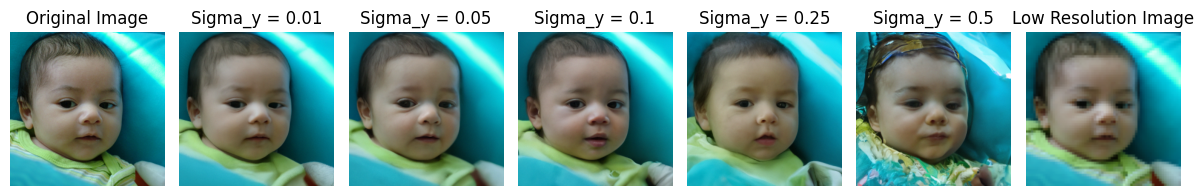

In [38]:
sigma_y_values = [0.01, 0.05, 0.1, 0.25, 0.5]

noiseless = False
num_steps = 100
seed = 42

n = len(sigma_y_values)

fig, axes = plt.subplots(1, n+2, figsize=(12, 8))

image = dataset[0].to(device)
y = measurement_operator(image.unsqueeze(0))

axes[0].imshow(standardize_img(image))
axes[0].axis('off')
axes[0].set_title("Original Image")

for i in range(n):
    sigma_y = sigma_y_values[i]
    
    y_noisy = y.clone() + sigma_y * torch.randn_like(y)
    
    sr_image = pigdm_sampler_ddim.sample(
        y=y_noisy,
        num_steps=num_steps,
        noiseless=noiseless,
        sigma_y=sigma_y,
        optimized = True,
        seed=seed,
    )

    
    axes[i+1].imshow(standardize_img(sr_image))
    axes[i+1].axis('off')
    axes[i+1].set_title(f"Sigma_y = {sigma_y}")


axes[n+1].imshow(standardize_img(y))
axes[n+1].axis('off')
axes[n+1].set_title("Low Resolution Image")



plt.tight_layout()
plt.show()

In [ ]:
def psnr_vs_sigma(sigma_values, PIGDM, times=5):
    psnr_values = []
    ssim_values = []

    n = len(dataset)
    for sigma_y in sigma_values:
        psnr_values_sigma = []
        ssim_values_sigma = []
        for _ in range(times):
            # Select Randomly an Image
            idx = np.random.randint(0, n)

            image = dataset[idx].to(device)

            measurement_operator = SuperResolutionOperator()
            pigdm_sampler = PIGDM(model, measurement_operator, guidance_factor=guidance_factor)
            y = measurement_operator(image.unsqueeze(0))
            y += sigma_y * torch.randn_like(y)
            sr_image = pigdm_sampler.sample(
                y=y,
                num_steps=num_steps,
                noiseless=noiseless,
                sigma_y=sigma_y,
                seed=seed
            )
            psnr_values_sigma.append(compute_psnr(image.unsqueeze(0), sr_image))
            ssim_values_sigma.append(compute_ssim(image.unsqueeze(0), sr_image))

        psnr_values.append(sum(psnr_values_sigma) / times)
        ssim_values.append(sum(ssim_values_sigma) / times)


    return psnr_values, ssim_values


sigma_values = [0.01, 0.025, 0.05, 0.1, 0.2, 0.4, 0.6, 1]

# DDPM vs Sigma
ddpm_psnr, ddpm_ssim = psnr_vs_sigma(sigma_values, PiGDM_DDPM)
# DDIM vs Sigma
ddim_psnr, ddim_ssim = psnr_vs_sigma(sigma_values, PiGDM_DDIM)

In [ ]:
plt.figure(figsize=(8, 5))  

# Plot first curve
plt.plot(sigma_values, ddim_psnr, marker='o', linestyle='-', color='b', label="PSNR vs Sigma_y (DDIM)")

plt.plot(sigma_values, ddpm_psnr, marker='s', linestyle='--', color='g', label="PSNR vs Sigma_y (DDPM)")

# Labels & Title
plt.xlabel("Sigma_y Values", fontsize=12)
plt.ylabel("PSNR (dB)", fontsize=12)
plt.title("PSNR vs Sigma for DDIM and DDPM", fontsize=14)

# Grid & Legend
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))  

# Plot first curve
plt.plot(sigma_values, ddim_ssim, marker='o', linestyle='-', color='b', label="SSIM vs Sigma_y (DDIM)")

plt.plot(sigma_values, ddpm_ssim, marker='s', linestyle='--', color='g', label="SSIM vs Sigma_y (DDPM)")

# Labels & Title
plt.xlabel("Sigma_y Values", fontsize=12)
plt.ylabel("SSIM", fontsize=12)
plt.title("SSIm vs Sigma for DDIM and DDPM", fontsize=14)

# Grid & Legend
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

# Show the plot
plt.show()